# Optimization with Gradients: An Example

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture
*"Optimization with gradients: An example"* (Week 2 — Gradients and Gradient Descent).

This notebook works a full example end to end:

- the **2D sauna** problem — find the coldest spot in a room
- the optimality condition: the tangent plane is flat, so $\nabla T = \mathbf{0}$
- the temperature function $T(x,y) = 85 - \tfrac{1}{90}\,x^2(x-6)\,y^2(y-6)$
- computing both partial derivatives
- solving $\nabla T = 0$ by the **"a product is zero ⟹ a factor is zero"** trick
- enumerating candidates and checking each → minimum at $(4,4)$, $T = 73.6$
- SymPy solving, a heat-map / 3D visualization, exercises, and a summary

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Gradients and Maxima/Minima*.

## 1. The problem: a two-dimensional sauna

> *"You are in a sauna and want to get to the coolest point... now you can move in any
> direction because you're standing anywhere in this room. It's a two-dimensional sauna."*

In Week 1 you could only move left/right (one variable). Now the sauna is a 2D room: at
each position $(x, y)$ the **temperature** is a function $T(x,y)$, drawn as a surface —
**red = hot (high)**, **blue = cold (low)**. The goal is the **coldest** point.

### The naive approach (foreshadowing gradient descent)

One way: stand somewhere, sample a few directions, step toward whichever is colder, and
repeat. That iterative idea becomes **gradient descent** in the next lectures. Here we
solve it **exactly** instead.

## 2. The optimality condition

> *"The coldest place is where, if you walk in any direction, you get hotter... the
> tangent plane is parallel to the floor because the two partial derivatives are both
> zero."*

So the coldest (or hottest) point satisfies

$$
\frac{\partial T}{\partial x} = 0 \qquad\text{and}\qquad \frac{\partial T}{\partial y} = 0,
\qquad\text{i.e.}\qquad \nabla T = \mathbf{0}.
$$

## 3. The temperature function

The lecture uses

$$
T(x,y) = 85 - \frac{1}{90}\,\underbrace{x^2(x-6)}_{A(x)}\,\underbrace{y^2(y-6)}_{B(y)} .
$$

It is more complicated than $x^2+y^2$, but the method is identical.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

x, y = sp.symbols('x y')
T = 85 - sp.Rational(1, 90) * x**2 * (x - 6) * y**2 * (y - 6)
print("T(x, y) =", sp.expand(T))

T(x, y) = -x**3*y**3/90 + x**3*y**2/15 + x**2*y**3/15 - 2*x**2*y**2/5 + 85


## 4. The partial derivatives

Treating $y$ as a constant and differentiating in $x$ (and vice versa):

$$
\frac{\partial T}{\partial x} = -\frac{1}{90}\,\big[x(3x-12)\big]\,y^2(y-6)
$$

$$
\frac{\partial T}{\partial y} = -\frac{1}{90}\,x^2(x-6)\,\big[y(3y-12)\big]
$$

(Here $\dfrac{d}{dx}\,x^2(x-6) = \dfrac{d}{dx}(x^3-6x^2) = 3x^2-12x = x(3x-12)$.)

In [2]:
Tx = sp.diff(T, x)
Ty = sp.diff(T, y)

print("∂T/∂x =", sp.factor(Tx))
print("∂T/∂y =", sp.factor(Ty))

∂T/∂x = -x*y**2*(x - 4)*(y - 6)/30
∂T/∂y = -x**2*y*(x - 6)*(y - 4)/30


## 5. Solving $\nabla T = 0$ — "a product is zero ⟹ a factor is zero"

Each partial derivative is a **product** of several factors. A product is zero only if at
least one factor is zero. From $\partial T/\partial x = 0$:

$$
x = 0, \quad 3x-12=0\;(x=4), \quad y^2=0\;(y=0), \quad y-6=0\;(y=6).
$$

From $\partial T/\partial y = 0$:

$$
x = 0, \quad x-6=0\;(x=6), \quad y=0, \quad 3y-12=0\;(y=4).
$$

A point is a critical point only if it makes **both** zero, which gives a grid of
candidates from $x \in \{0,4,6\}$ and $y \in \{0,4,6\}$ (some lie outside the sauna).

In [3]:
# Let SymPy find the critical points directly
crit = sp.solve([Tx, Ty], [x, y], dict=True)
print("Critical points (∇T = 0):")
for sol in crit:
    print("  ", sol)

Critical points (∇T = 0):
   {x: 0}
   {y: 0}
   {x: 4, y: 0}
   {x: 4, y: 4}
   {x: 6, y: 6}


## 6. Checking the candidates

> *"For $x=0$ or $y=0$, those all give $85$ as the temperature, so they're not the
> minimum. The only minimum is $x=4,\ y=4$, where the temperature is $73.6$."*

Whenever $x=0$ or $y=0$ the product term vanishes and $T = 85$ (the hot baseline). The
genuine **interior minimum** is at $(4, 4)$.

In [4]:
def Tnum(xv, yv):
    return 85 - (1/90) * xv**2 * (xv - 6) * yv**2 * (yv - 6)

candidates = [(cx, cy) for cx in (0, 4, 6) for cy in (0, 4, 6)]
print(f"{'(x, y)':>10} | {'T':>8} | inside 0..5 room?")
print("-" * 40)
for (cx, cy) in candidates:
    inside = (0 <= cx <= 5) and (0 <= cy <= 5)
    print(f"{str((cx, cy)):>10} | {Tnum(cx, cy):8.3f} | {'yes' if inside else 'no (outside)'}")

print(f"\nMinimum at (4, 4): T = {Tnum(4, 4):.3f}")

    (x, y) |        T | inside 0..5 room?
----------------------------------------
    (0, 0) |   85.000 | yes
    (0, 4) |   85.000 | yes
    (0, 6) |   85.000 | no (outside)
    (4, 0) |   85.000 | yes
    (4, 4) |   73.622 | yes
    (4, 6) |   85.000 | no (outside)
    (6, 0) |   85.000 | no (outside)
    (6, 4) |   85.000 | no (outside)
    (6, 6) |   85.000 | no (outside)

Minimum at (4, 4): T = 73.622


## 7. Visualizing the sauna

The surface (and matching heat-map) of $T(x,y)$ over the room. The coldest point — the
blue basin — sits at $(4,4)$.

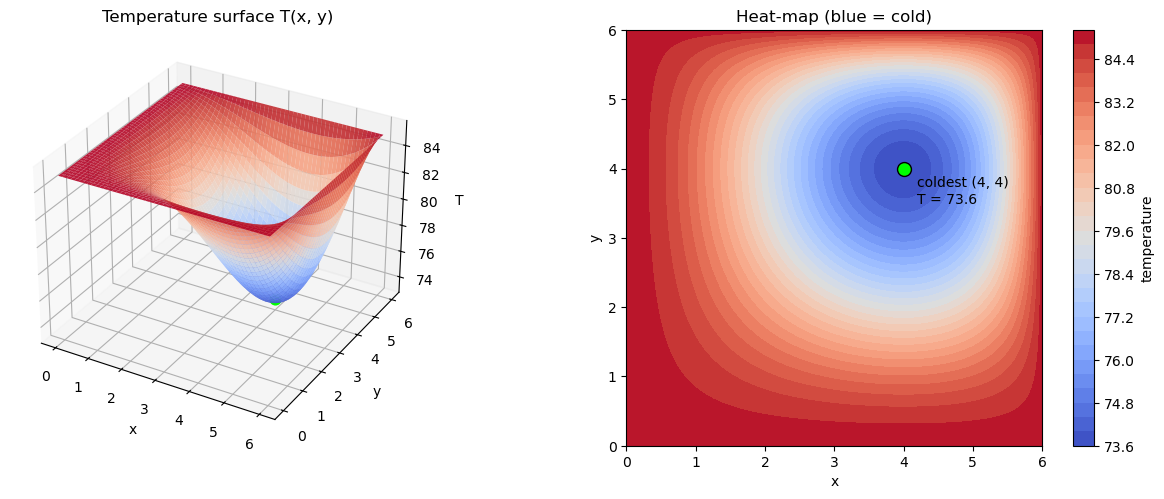

In [5]:
gx = np.linspace(0, 6, 200)
gy = np.linspace(0, 6, 200)
X, Y = np.meshgrid(gx, gy)
Z = 85 - (1/90) * X**2 * (X - 6) * Y**2 * (Y - 6)

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X, Y, Z, cmap="coolwarm", alpha=0.9)
ax.scatter([4], [4], [Tnum(4, 4)], color="lime", s=60)
ax.set_title("Temperature surface T(x, y)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("T")

ax2 = fig.add_subplot(1, 2, 2)
hm = ax2.contourf(X, Y, Z, levels=30, cmap="coolwarm")
plt.colorbar(hm, ax=ax2, label="temperature")
ax2.plot(4, 4, "o", color="lime", markersize=10, markeredgecolor="black")
ax2.annotate("coldest (4, 4)\nT = 73.6", (4, 4),
             textcoords="offset points", xytext=(10, -25))
ax2.set_title("Heat-map (blue = cold)")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_aspect("equal")

plt.tight_layout()
plt.show()

## 8. The general recipe

This example follows the same pattern as the one-variable case:

1. Compute every partial derivative (the gradient).
2. Set them all to zero and **solve the system** $\nabla T = 0$.
3. You get a list of **candidate** points.
4. **Check each candidate** to see which is the minimum (or maximum).

> *"Just like we did for one variable: you set the derivative equal to zero, that gives
> you candidates, and then you check them individually."*

## 9. Exercises

### Basic
1. State the optimality condition for an interior min/max of $T(x,y)$.
2. Why does every point with $x=0$ give $T = 85$ for this temperature function?

### Intermediate
3. Verify by hand that $(4,4)$ satisfies $\partial T/\partial x = 0$ and
   $\partial T/\partial y = 0$.
4. Compute $T(4, 4)$ and confirm it equals $73.6$ (to one decimal).

### Advanced
5. For $f(x,y) = x^2(x-6) + y^2(y-6)$, find **all** critical points by solving
   $\nabla f = 0$.
6. Explain why solving $\nabla T = 0$ alone does not tell you whether a critical point is
   a minimum, maximum, or saddle — and name the tool that does.

## 10. Solutions / Checks

In [6]:
x, y = sp.symbols('x y')
T = 85 - sp.Rational(1, 90) * x**2 * (x - 6) * y**2 * (y - 6)
Tx, Ty = sp.diff(T, x), sp.diff(T, y)

# 3. check (4,4)
print("3. ∂T/∂x at (4,4) =", Tx.subs({x: 4, y: 4}),
      ", ∂T/∂y at (4,4) =", Ty.subs({x: 4, y: 4}))
# 4. value
print("4. T(4,4) =", float(T.subs({x: 4, y: 4})))
# 5. critical points of a related function
f = x**2*(x - 6) + y**2*(y - 6)
print("5. critical points:", sp.solve([sp.diff(f, x), sp.diff(f, y)], [x, y], dict=True))
print("6. ∇T = 0 finds critical points only; the Hessian (2nd derivatives) classifies "
      "them as min / max / saddle.")

3. ∂T/∂x at (4,4) = 0 , ∂T/∂y at (4,4) = 0
4. T(4,4) = 73.62222222222222
5. critical points: [{x: 0, y: 0}, {x: 0, y: 4}, {x: 4, y: 0}, {x: 4, y: 4}]
6. ∇T = 0 finds critical points only; the Hessian (2nd derivatives) classifies them as min / max / saddle.


## 11. Conclusion

- Optimizing a multivariable function = the 2D version of "set the slope to zero":
  solve $\nabla T = \mathbf{0}$.
- For the sauna temperature $T(x,y) = 85 - \tfrac{1}{90}x^2(x-6)\,y^2(y-6)$, the partial
  derivatives factor nicely; a **product is zero when a factor is zero**, giving a grid of
  candidates.
- Checking the candidates, the coldest spot is $(4, 4)$ with $T = 73.6$.
- Solving the system is exact but can be tedious or impossible in closed form — which
  motivates the **iterative** approach, **gradient descent**, coming next.

## Appendix — Source transcript

Transcribed from the Coursera interactive transcript of
*"Optimization with gradients: An example"*
(*Calculus for Machine Learning and Data Science*, Week 2), read via the
Claude-for-Chrome browser extension. Key spoken points, lightly cleaned:

> A two-dimensional sauna: at each position $(x,y)$ the temperature is a surface (red hot,
> blue cold) and you want the coldest point. That point is where walking in any direction
> gets hotter — the tangent plane is parallel to the floor, so $\partial T/\partial x =
> \partial T/\partial y = 0$. With $T = 85 - \tfrac{1}{90}x^2(x-6)y^2(y-6)$, the partials
> are $\partial T/\partial x = -\tfrac{1}{90}x(3x-12)y^2(y-6)$ and $\partial T/\partial y
> = -\tfrac{1}{90}x^2(x-6)y(3y-12)$. Setting each product to zero gives candidates from
> $x,y \in \{0,4,6\}$; points with $x=0$ or $y=0$ give $T=85$ (not the minimum), and the
> minimum is $(4,4)$ with $T=73.6$. As in one variable: set derivatives to zero, get
> candidates, then check them individually.